# Exploração e Experimentação de Arquiteturas

Dataset: Retailrocket Recommender System Dataset

Link: https://www.kaggle.com/datasets/retailrocket/ecommerce-dataset/data

# O que encontrar neste notebook?

Esse é notebook de caráter exploratório e experimental, foi abordado os seguintes tópicos:

- Análise Exploratória Inicial para investigação de possíveis etapas de pré-processamento;
- Exploração de diferentes estratégias para 

# Contexto dos Dados

O dataset contém 3 arquivos principais: 
1. `events.csv`: Contém dados de interação que foram coletados durante um período de 4 meses e meio. 
2. `item_properties`
3. `category_tree`



# Metadata

## Events

- **timestamp**: Tempo quando o evento ocorreu, em ms desde 01-01-1970.
- **visitorid**: ID único do visitante.
- **event**: tipo do evento ("view". "addtocart" ou "transaction")
- **itemid**: ID único do produto
- **transactionid**: ID único de transação (apenas para as transações, está vazio para os demais tipos de eventos)

## Category Tree

- **categoryid**: ID único da categoria
- **parentid**: ID de uma categoria parente. é vazia quando na existir parentesco.

## Item Properties

- **timestamp**
- **itemid**: ID único do produto.
- **property**: 
- **value**: valor do produto.

# Objetivos

- Explorar diversos algoritmos de recomendação de produtos com a biblioteca PyTorch;
- Identificar e Validar Etapas de pré-processamento;
- Propor um pipeline mvp.

# Importando as Bibliotecas

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict



# Load Data

In [2]:
category_tree = pd.read_csv('../data/raw/category_tree.csv')
events = pd.read_csv('../data/raw/events.csv')
prop1 = pd.read_csv('../data/raw/item_properties_part1.csv')
prop2 = pd.read_csv('../data/raw/item_properties_part2.csv')


# combine item properties
item_properties = pd.concat([prop1, prop2], ignore_index=True)

print('Category Tree shape:', category_tree.shape)
print('Events shape:', events.shape)
print('Item Properties shape:', item_properties.shape)

Category Tree shape: (1669, 2)
Events shape: (2756101, 5)
Item Properties shape: (20275902, 4)


# EDA Inicial

## Events

In [3]:
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [4]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


In [5]:
events.isnull().sum()

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

In [6]:
events.nunique()

timestamp        2750455
visitorid        1407580
event                  3
itemid            235061
transactionid      17672
dtype: int64

In [7]:
events['event'].value_counts()

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

In [8]:
events["event"].value_counts(normalize=True).mul(100)

event
view           96.669607
addtocart       2.515583
transaction     0.814810
Name: proportion, dtype: float64

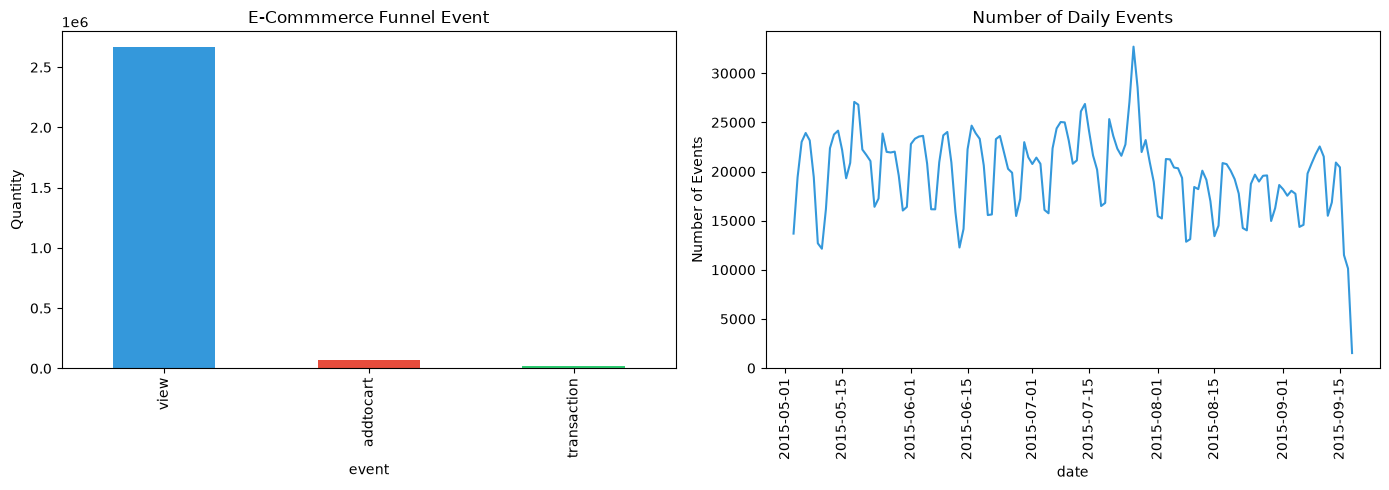

Total events: 2,756,101
Unique users: 1,407,580
Unique product: 235,061
View: 2,664,312
Add to cart: 69,332
Transaction: 22,457


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Event distribution
events['event'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db','#e74c3c','#2ecc71'])
axes[0].set_title('E-Commmerce Funnel Event')
axes[0].set_ylabel('Quantity')

# Convert Timestamp to history and daily event count
events['date'] = pd.to_datetime(events['timestamp'], unit='ms').dt.date
daily = events.groupby('date').size()
daily.plot(ax=axes[1], color='#3498db')
axes[1].set_title('Number of Daily Events')
axes[1].set_ylabel('Number of Events')

axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

# Basic statistics
print(f"Total events: {len(events):,}")
print(f"Unique users: {events['visitorid'].nunique():,}")
print(f"Unique product: {events['itemid'].nunique():,}")
print(f"View: {len(events[events['event']=='view']):,}")
print(f"Add to cart: {len(events[events['event']=='addtocart']):,}")
print(f"Transaction: {len(events[events['event']=='transaction']):,}")

In [10]:
events.groupby('visitorid').size().describe()

count    1.407580e+06
mean     1.958042e+00
std      1.258049e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
dtype: float64

## Category Tree

In [11]:
category_tree.head()

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


In [12]:
category_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


In [13]:
category_tree.nunique()

categoryid    1669
parentid       362
dtype: int64

## Item Properties

In [14]:
item_properties.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [15]:
item_properties.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20275902 entries, 0 to 20275901
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 618.8+ MB


In [16]:
item_properties.nunique()

timestamp         18
itemid        417053
property        1104
value        1966868
dtype: int64

## Conclusão

### Usuários

- Quantos usuários tem apenas 1 evento?
- Quantos têm mais de 5? mais de 10?

### Produtos

- quantos produtos foram vistost apenas uma vez?
- quantos produtos concentram 80% das interações?
- funil de conversão.



- O principal desafio dessa base é a grande esparsidade dos dados. Cogitar pesos por interação.
- 1.4 m de usuários e 417mil produtos. maioria dos usuários possui pouca interação.

# Preprocessing

In [17]:
events["datetime"] = pd.to_datetime(events["timestamp"], unit="ms")

print(events["datetime"].min(), events["datetime"].max())

events = events.sort_values("datetime").reset_index(drop=True)

2015-05-03 03:00:04.384000 2015-09-18 02:59:47.788000


In [18]:
cutoff = events["datetime"].quantile(0.80)

train = events[events["datetime"] <= cutoff].copy()
test = events[events["datetime"] > cutoff].copy()

print(train["datetime"].min(), train["datetime"].max())
print(test["datetime"].min(), test["datetime"].max())

2015-05-03 03:00:04.384000 2015-08-18 04:23:31.966000
2015-08-18 04:23:37.919000 2015-09-18 02:59:47.788000


# Level 0 - Popularidade

Recomendar os produtos mais populares.

In [19]:
def build_popularity_model(train, event_weights):
    train = train.copy()
    train["event_weight"] = train["event"].map(event_weights)
    
    item_popularity = (
        train
        .groupby("itemid")
        .agg(
            popularity_score=("event_weight", "sum"),
            n_events=("event", "count"),
            n_users=("visitorid", "nunique")
        )
        .sort_values("popularity_score", ascending=False)
        .reset_index()
    )
    
    return item_popularity

In [20]:
def recommend_popular_items(item_popularity, users, k=10):
    top_k_items = item_popularity.head(k)["itemid"].tolist()
    
    recommendations = {
        user: top_k_items
        for user in users
    }
    
    return recommendations

In [21]:
def hit_rate_at_k(recommended_items, relevant_items):
    recommended_set = set(recommended_items)
    return int(len(recommended_set & relevant_items) > 0)

def precision_at_k(recommended_items, relevant_items, k):
    recommended_items = recommended_items[:k]
    hits = len(set(recommended_items) & relevant_items)
    return hits / k

def recall_at_k(recommended_items, relevant_items, k):
    recommended_items = recommended_items[:k]
    
    if len(relevant_items) == 0:
        return 0
    
    hits = len(set(recommended_items) & relevant_items)
    return hits / len(relevant_items)

def ndcg_at_k(recommended_items, relevant_items, k):
    recommended_items = recommended_items[:k]
    
    dcg = 0.0
    
    for i, item in enumerate(recommended_items):
        if item in relevant_items:
            dcg += 1 / np.log2(i + 2)
    
    ideal_hits = min(len(relevant_items), k)
    
    if ideal_hits == 0:
        return 0
    
    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))
    
    return dcg / idcg

In [22]:
def evaluate_recommender(recommendations, ground_truth, k=10):
    hit_rates = []
    precisions = []
    recalls = []
    ndcgs = []
    
    for user, relevant_items in ground_truth.items():
        recommended_items = recommendations.get(user, [])
        
        hit_rates.append(
            hit_rate_at_k(recommended_items, relevant_items)
        )
        
        precisions.append(
            precision_at_k(recommended_items, relevant_items, k)
        )
        
        recalls.append(
            recall_at_k(recommended_items, relevant_items, k)
        )
        
        ndcgs.append(
            ndcg_at_k(recommended_items, relevant_items, k)
        )
    
    metrics = {
        f"hit_rate@{k}": np.mean(hit_rates),
        f"precision@{k}": np.mean(precisions),
        f"recall@{k}": np.mean(recalls),
        f"ndcg@{k}": np.mean(ndcgs)
    }
    
    return metrics

In [23]:
event_weights = {
    "view": 1,
    "addtocart": 5,
    "transaction": 10
}

K = 10

item_popularity = build_popularity_model(
    train=train,
    event_weights=event_weights
)

test_users = test["visitorid"].unique()

recommendations = recommend_popular_items(
    item_popularity=item_popularity,
    users=test_users,
    k=K
)

test_relevant = test[
    test["event"].isin(
        ["addtocart", "transaction"]
    )
]

ground_truth = (
    test_relevant
    .groupby("visitorid")["itemid"]
    .apply(set)
    .to_dict()
)

metrics = evaluate_recommender(
    recommendations=recommendations,
    ground_truth=ground_truth,
    k=K
)

results = []

results.append({
    "model": "Popularity Weighted",
    "k": K,
    **metrics
})

results_df = pd.DataFrame(results)
results_df

,model,k,hit_rate@10,precision@10,recall@10,ndcg@10
0,Popularity Weighted,10,0.015822,0.001594,0.010752,0.008991


In [24]:
item_popularity.head(10)

,itemid,popularity_score,n_events,n_users
0,461686,3731,2015,966
1,257040,2212,1613,972
2,5411,2181,2149,1920
3,309778,1943,1616,1046
4,7943,1938,1254,687
5,187946,1833,1829,1553
6,48030,1831,1095,614
7,312728,1812,961,525
8,369447,1803,1204,607
9,445351,1658,947,558


# Level 1 - Basket Analysis

Algoritmo Apriori - "se ele compra esse, provavelmente comprará aquele"

In [25]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [26]:
def build_baskets(train, event_filter=None):
    train_basket = train.copy()

    if event_filter is not None:
        train_basket = train_basket[
            train_basket["event"].isin(event_filter)
        ].copy()

    baskets = (
        train_basket
        .groupby("visitorid")["itemid"]
        .apply(lambda x: list(set(x)))
        .tolist()
    )

    baskets = [
        basket for basket in baskets
        if len(basket) >= 2
    ]

    return baskets, train_basket

In [27]:
def build_transaction_matrix(baskets):
    te = TransactionEncoder()

    basket_matrix = te.fit(baskets).transform(baskets)

    basket_df = pd.DataFrame(
        basket_matrix,
        columns=te.columns_
    )

    return basket_df, te

In [28]:
def train_apriori_rules(
    basket_df,
    min_support=0.001,
    min_confidence=0.05,
    min_lift=1.0
):
    frequent_itemsets = apriori(
        basket_df,
        min_support=min_support,
        use_colnames=True
    )

    rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=min_confidence
    )

    rules_filtered = rules[
        (rules["lift"] > min_lift)
        &
        (rules["confidence"] >= min_confidence)
    ].copy()

    rules_filtered = rules_filtered.sort_values(
        ["confidence", "lift"],
        ascending=False
    )

    return frequent_itemsets, rules_filtered

In [29]:
def build_apriori_recommendation_dict(rules):
    recommendation_dict = defaultdict(list)

    for _, row in rules.iterrows():
        antecedents = list(row["antecedents"])
        consequents = list(row["consequents"])

        if len(antecedents) == 1:
            antecedent = antecedents[0]

            for consequent in consequents:
                recommendation_dict[antecedent].append(
                    {
                        "itemid": consequent,
                        "confidence": row["confidence"],
                        "lift": row["lift"],
                        "support": row["support"]
                    }
                )

    return recommendation_dict

In [30]:
def get_popular_items(train, event_weights, k=10):
    train_pop = train.copy()

    train_pop["event_weight"] = train_pop["event"].map(event_weights)

    popular_items = (
        train_pop
        .groupby("itemid")["event_weight"]
        .sum()
        .sort_values(ascending=False)
        .head(k)
        .index
        .tolist()
    )

    return popular_items

In [31]:
def recommend_apriori_user(
    user_items,
    recommendation_dict,
    popular_items=None,
    k=10
):
    candidate_scores = defaultdict(float)

    for item in user_items:
        if item in recommendation_dict:
            for rec in recommendation_dict[item]:
                candidate_item = rec["itemid"]

                if candidate_item not in user_items:
                    score = rec["confidence"] * rec["lift"]
                    candidate_scores[candidate_item] += score

    ranked_items = sorted(
        candidate_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = [
        item for item, score in ranked_items[:k]
    ]

    if len(recommendations) < k and popular_items is not None:
        recommendations += [
            item for item in popular_items
            if item not in recommendations
            and item not in user_items
        ][:k - len(recommendations)]

    return recommendations

In [32]:
def generate_apriori_recommendations(
    users,
    user_history,
    recommendation_dict,
    popular_items=None,
    k=10
):
    recommendations = {}

    for user in users:
        user_items = user_history.get(user, set())

        recommendations[user] = recommend_apriori_user(
            user_items=user_items,
            recommendation_dict=recommendation_dict,
            popular_items=popular_items,
            k=k
        )

    return recommendations

In [33]:
event_weights = {
    "view": 1,
    "addtocart": 5,
    "transaction": 10
}

K = 10

In [34]:
baskets, train_basket = build_baskets(
    train=train,
    event_filter=["addtocart", "transaction"]
)

In [35]:
basket_df, te = build_transaction_matrix(
    baskets=baskets
)

In [36]:
frequent_itemsets, rules = train_apriori_rules(
    basket_df=basket_df,
    min_support=0.001,
    min_confidence=0.05,
    min_lift=1.0
)

In [37]:
recommendation_dict = build_apriori_recommendation_dict(
    rules=rules
)

In [38]:
user_history = (
    train_basket
    .groupby("visitorid")["itemid"]
    .apply(set)
    .to_dict()
)

In [39]:
popular_items = get_popular_items(
    train=train,
    event_weights=event_weights,
    k=K
)

In [40]:
test_users = test["visitorid"].unique()

In [41]:
recommendations = generate_apriori_recommendations(
    users=test_users,
    user_history=user_history,
    recommendation_dict=recommendation_dict,
    popular_items=popular_items,
    k=K
)

In [42]:
test_relevant = test[
    test["event"].isin(
        ["addtocart", "transaction"]
    )
]

ground_truth = (
    test_relevant
    .groupby("visitorid")["itemid"]
    .apply(set)
    .to_dict()
)

In [43]:
metrics = evaluate_recommender(
    recommendations=recommendations,
    ground_truth=ground_truth,
    k=K
)

results.append({
    "model": "Apriori",
    "k": K,
    **metrics
})

results_df = pd.DataFrame(results)
results_df

,model,k,hit_rate@10,precision@10,recall@10,ndcg@10
0,Popularity Weighted,10,0.015822,0.001594,0.010752,0.008991
1,Apriori,10,0.015222,0.001534,0.010057,0.008441


# Level 2 - Item-Based CF

Recomendar itens parecidos com os itens que o usuário já interagiu no passado.

In [44]:
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

In [45]:
def build_user_item_matrix(train, event_weights):
    train = train.copy()

    train["event_weight"] = train["event"].map(event_weights)

    user_item_interactions = (
        train
        .groupby(["visitorid", "itemid"])["event_weight"]
        .sum()
        .reset_index()
    )

    user_ids = user_item_interactions["visitorid"].unique()
    item_ids = user_item_interactions["itemid"].unique()

    user_to_idx = {
        user: idx
        for idx, user in enumerate(user_ids)
    }

    item_to_idx = {
        item: idx
        for idx, item in enumerate(item_ids)
    }

    idx_to_user = {
        idx: user
        for user, idx in user_to_idx.items()
    }

    idx_to_item = {
        idx: item
        for item, idx in item_to_idx.items()
    }

    user_item_interactions["user_idx"] = (
        user_item_interactions["visitorid"].map(user_to_idx)
    )

    user_item_interactions["item_idx"] = (
        user_item_interactions["itemid"].map(item_to_idx)
    )

    user_item_matrix = csr_matrix(
        (
            user_item_interactions["event_weight"],
            (
                user_item_interactions["user_idx"],
                user_item_interactions["item_idx"]
            )
        ),
        shape=(len(user_to_idx), len(item_to_idx))
    )

    return (
        user_item_matrix,
        user_to_idx,
        item_to_idx,
        idx_to_user,
        idx_to_item,
        user_item_interactions
    )

In [46]:
def build_item_similarity(user_item_matrix):
    item_user_matrix = user_item_matrix.T

    item_similarity = cosine_similarity(
        item_user_matrix,
        dense_output=False
    )

    return item_similarity

In [47]:
def get_popular_items(train, event_weights, k=10):
    train = train.copy()

    train["event_weight"] = train["event"].map(event_weights)

    popular_items = (
        train
        .groupby("itemid")["event_weight"]
        .sum()
        .sort_values(ascending=False)
        .head(k)
        .index
        .tolist()
    )

    return popular_items

In [48]:
def recommend_item_based_cf(
    user_id,
    user_item_matrix,
    item_similarity,
    user_to_idx,
    idx_to_item,
    popular_items=None,
    k=10
):
    if user_id not in user_to_idx:
        return popular_items[:k] if popular_items is not None else []

    user_idx = user_to_idx[user_id]

    user_vector = user_item_matrix[user_idx]

    interacted_items = user_vector.indices

    scores = user_vector @ item_similarity

    scores = scores.toarray().ravel()

    scores[interacted_items] = -np.inf

    top_items_idx = np.argsort(scores)[::-1]

    recommended_items = []

    for item_idx in top_items_idx:
        if len(recommended_items) >= k:
            break

        if scores[item_idx] == -np.inf:
            continue

        recommended_items.append(
            idx_to_item[item_idx]
        )

    if len(recommended_items) < k and popular_items is not None:
        recommended_items += [
            item for item in popular_items
            if item not in recommended_items
        ][:k - len(recommended_items)]

    return recommended_items

In [49]:
def generate_item_based_recommendations(
    users,
    user_item_matrix,
    item_similarity,
    user_to_idx,
    idx_to_item,
    popular_items=None,
    k=10
):
    recommendations = {}

    for user in users:
        recommendations[user] = recommend_item_based_cf(
            user_id=user,
            user_item_matrix=user_item_matrix,
            item_similarity=item_similarity,
            user_to_idx=user_to_idx,
            idx_to_item=idx_to_item,
            popular_items=popular_items,
            k=k
        )

    return recommendations

In [50]:
event_weights = {
    "view": 1,
    "addtocart": 5,
    "transaction": 10
}

K = 10

In [51]:
(
    user_item_matrix,
    user_to_idx,
    item_to_idx,
    idx_to_user,
    idx_to_item,
    user_item_interactions
) = build_user_item_matrix(
    train=train,
    event_weights=event_weights
)

In [52]:
item_similarity = build_item_similarity(
    user_item_matrix=user_item_matrix
)

In [53]:
popular_items = get_popular_items(
    train=train,
    event_weights=event_weights,
    k=K
)

In [54]:
test_users = test["visitorid"].unique()

In [55]:
recommendations = generate_item_based_recommendations(
    users=test_users,
    user_item_matrix=user_item_matrix,
    item_similarity=item_similarity,
    user_to_idx=user_to_idx,
    idx_to_item=idx_to_item,
    popular_items=popular_items,
    k=K
)

In [56]:
test_relevant = test[
    test["event"].isin(
        ["addtocart", "transaction"]
    )
]

ground_truth = (
    test_relevant
    .groupby("visitorid")["itemid"]
    .apply(set)
    .to_dict()
)

In [57]:
metrics = evaluate_recommender(
    recommendations=recommendations,
    ground_truth=ground_truth,
    k=K
)

results.append({
    "model": "Item-Based CF",
    "k": K,
    **metrics
})

results_df = pd.DataFrame(results)
results_df

,model,k,hit_rate@10,precision@10,recall@10,ndcg@10
0,Popularity Weighted,10,0.015822,0.001594,0.010752,0.008991
1,Apriori,10,0.015222,0.001534,0.010057,0.008441
2,Item-Based CF,10,0.014623,0.001582,0.009983,0.008025


# Level 3 - Matrix Factorization (ALS)

In [60]:
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares

In [61]:
def build_als_user_item_matrix(train, event_weights):
    train_als = train.copy()

    train_als["event_weight"] = train_als["event"].map(event_weights)

    user_item_interactions = (
        train_als
        .groupby(["visitorid", "itemid"])["event_weight"]
        .sum()
        .reset_index()
    )

    user_ids = user_item_interactions["visitorid"].unique()
    item_ids = user_item_interactions["itemid"].unique()

    user_to_idx = {
        user: idx
        for idx, user in enumerate(user_ids)
    }

    item_to_idx = {
        item: idx
        for idx, item in enumerate(item_ids)
    }

    idx_to_user = {
        idx: user
        for user, idx in user_to_idx.items()
    }

    idx_to_item = {
        idx: item
        for item, idx in item_to_idx.items()
    }

    user_item_interactions["user_idx"] = (
        user_item_interactions["visitorid"].map(user_to_idx)
    )

    user_item_interactions["item_idx"] = (
        user_item_interactions["itemid"].map(item_to_idx)
    )

    user_item_matrix = csr_matrix(
        (
            user_item_interactions["event_weight"],
            (
                user_item_interactions["user_idx"],
                user_item_interactions["item_idx"]
            )
        ),
        shape=(len(user_to_idx), len(item_to_idx))
    )

    return (
        user_item_matrix,
        user_to_idx,
        item_to_idx,
        idx_to_user,
        idx_to_item,
        user_item_interactions,
        train_als
    )

In [62]:
def train_als_model(
    user_item_matrix,
    factors=64,
    regularization=0.1,
    iterations=20,
    alpha=40,
    random_state=42
):
    user_item_confidence = (
        user_item_matrix * alpha
    ).tocsr()

    model = AlternatingLeastSquares(
        factors=factors,
        regularization=regularization,
        iterations=iterations,
        random_state=random_state
    )

    model.fit(user_item_confidence)

    expected_users, expected_items = user_item_matrix.shape

    assert model.user_factors.shape[0] == expected_users
    assert model.item_factors.shape[0] == expected_items

    return model

In [63]:
def get_popular_items(train, event_weights, k=10):
    train_pop = train.copy()

    train_pop["event_weight"] = train_pop["event"].map(event_weights)

    popular_items = (
        train_pop
        .groupby("itemid")["event_weight"]
        .sum()
        .sort_values(ascending=False)
        .head(k)
        .index
        .tolist()
    )

    return popular_items

In [64]:
def recommend_als_user(
    user_id,
    als_model,
    user_item_matrix,
    user_to_idx,
    idx_to_item,
    popular_items=None,
    k=10
):
    if user_id not in user_to_idx:
        return popular_items[:k] if popular_items is not None else []

    user_idx = user_to_idx[user_id]

    item_indices, scores = als_model.recommend(
        userid=user_idx,
        user_items=user_item_matrix[user_idx],
        N=k,
        filter_already_liked_items=True
    )

    recommendations = [
        idx_to_item[item_idx]
        for item_idx in item_indices
    ]

    if len(recommendations) < k and popular_items is not None:
        recommendations += [
            item for item in popular_items
            if item not in recommendations
        ][:k - len(recommendations)]

    return recommendations

In [65]:
def generate_als_recommendations(
    users,
    als_model,
    user_item_matrix,
    user_to_idx,
    idx_to_item,
    popular_items=None,
    k=10
):
    recommendations = {}

    for user in users:
        recommendations[user] = recommend_als_user(
            user_id=user,
            als_model=als_model,
            user_item_matrix=user_item_matrix,
            user_to_idx=user_to_idx,
            idx_to_item=idx_to_item,
            popular_items=popular_items,
            k=k
        )

    return recommendations

In [66]:
event_weights = {
    "view": 1,
    "addtocart": 5,
    "transaction": 10
}

K = 10

In [67]:
(
    user_item_matrix,
    user_to_idx,
    item_to_idx,
    idx_to_user,
    idx_to_item,
    user_item_interactions,
    train_als
) = build_als_user_item_matrix(
    train=train,
    event_weights=event_weights
)

In [68]:
als_model = train_als_model(
    user_item_matrix=user_item_matrix,
    factors=64,
    regularization=0.1,
    iterations=20,
    alpha=40,
    random_state=42
)

c:\Users\jooar\ds\portfolio\mle-f2-tech-challenge-fiap\.venv\Lib\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 16 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 20/20 [00:23<00:00,  1.18s/it]


In [69]:
popular_items = get_popular_items(
    train=train,
    event_weights=event_weights,
    k=K
)

In [70]:
test_users = test["visitorid"].unique()
test_users[:10]

array([ 384670, 1166298,  531293,   86098,  290950, 1031818,   89163,
       1374145,  415004,  789995])

In [71]:
recommendations = generate_als_recommendations(
    users=test_users,
    als_model=als_model,
    user_item_matrix=user_item_matrix,
    user_to_idx=user_to_idx,
    idx_to_item=idx_to_item,
    popular_items=popular_items,
    k=K
)

In [72]:
test_relevant = test[
    test["event"].isin(
        ["addtocart", "transaction"]
    )
]

ground_truth = (
    test_relevant
    .groupby("visitorid")["itemid"]
    .apply(set)
    .to_dict()
)

In [73]:
metrics = evaluate_recommender(
    recommendations=recommendations,
    ground_truth=ground_truth,
    k=K
)

results.append({
    "model": "ALS",
    "k": K,
    **metrics
})

results_df = pd.DataFrame(results)
results_df

,model,k,hit_rate@10,precision@10,recall@10,ndcg@10
0,Popularity Weighted,10,0.015822,0.001594,0.010752,0.008991
1,Apriori,10,0.015222,0.001534,0.010057,0.008441
2,Item-Based CF,10,0.014623,0.001582,0.009983,0.008025
3,ALS,10,0.016661,0.001690,0.011297,0.008686


In [74]:
als_configs = [
    {
        "factors": 32,
        "regularization": 0.1,
        "iterations": 20,
        "alpha": 20
    },
    {
        "factors": 64,
        "regularization": 0.1,
        "iterations": 20,
        "alpha": 40
    },
    {
        "factors": 128,
        "regularization": 0.1,
        "iterations": 30,
        "alpha": 40
    }
]

In [75]:
ALS_results = []
for config in als_configs:
    als_model = train_als_model(
        user_item_matrix=user_item_matrix,
        factors=config["factors"],
        regularization=config["regularization"],
        iterations=config["iterations"],
        alpha=config["alpha"],
        random_state=42
    )

    recommendations = generate_als_recommendations(
        users=test_users,
        als_model=als_model,
        user_item_matrix=user_item_matrix,
        user_to_idx=user_to_idx,
        idx_to_item=idx_to_item,
        popular_items=popular_items,
        k=K
    )

    metrics = evaluate_recommender(
        recommendations=recommendations,
        ground_truth=ground_truth,
        k=K
    )

    ALS_results.append({
        "model": f"ALS_f{config['factors']}_a{config['alpha']}",
        "k": K,
        **metrics
    })

ALS_results_df = pd.DataFrame(ALS_results)
ALS_results_df

100%|██████████| 30/30 [00:39<00:00,  1.31s/it]


,model,k,hit_rate@10,precision@10,recall@10,ndcg@10
0,ALS_f32_a20,10,0.016061,0.001642,0.010891,0.008472
1,ALS_f64_a40,10,0.016661,0.001690,0.011297,0.008686
2,ALS_f128_a40,10,0.017500,0.001822,0.011785,0.008928


# Level 4 - Neural Collaborative Filtering (NCF)

In [76]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

In [77]:
RANDOM_STATE = 42
K = 10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [78]:
# negativas são criadas amostrando itens que o usuário não interagiu
def generate_negative_samples(
    positive_df,
    user_col="user_idx",
    item_col="item_idx",
    num_items=None,
    num_negatives=4,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    user_positive_items = (
        positive_df
        .groupby(user_col)[item_col]
        .apply(set)
        .to_dict()
    )

    negatives = []

    for user_idx, positive_items in user_positive_items.items():
        positive_items = set(positive_items)

        n_samples = len(positive_items) * num_negatives
        sampled = 0

        while sampled < n_samples:
            item_idx = rng.integers(0, num_items)

            if item_idx not in positive_items:
                negatives.append({
                    user_col: user_idx,
                    item_col: item_idx,
                    "label": 0
                })
                sampled += 1

    negative_df = pd.DataFrame(negatives)

    return negative_df

In [79]:
class NCFDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(
            df["user_idx"].values,
            dtype=torch.long
        )

        self.items = torch.tensor(
            df["item_idx"].values,
            dtype=torch.long
        )

        self.labels = torch.tensor(
            df["label"].values,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.users[idx],
            self.items[idx],
            self.labels[idx]
        )

In [80]:
class SimpleNCF(nn.Module):
    def __init__(
        self,
        num_users,
        num_items,
        embedding_dim=64,
        hidden_dims=(128, 64),
        dropout=0.2
    ):
        super().__init__()

        self.user_embedding = nn.Embedding(
            num_users,
            embedding_dim
        )

        self.item_embedding = nn.Embedding(
            num_items,
            embedding_dim
        )

        layers = []
        input_dim = embedding_dim * 2

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim

        layers.append(nn.Linear(input_dim, 1))

        self.mlp = nn.Sequential(*layers)

    def forward(self, user_idx, item_idx):
        user_emb = self.user_embedding(user_idx)
        item_emb = self.item_embedding(item_idx)

        x = torch.cat([user_emb, item_emb], dim=1)

        logits = self.mlp(x).squeeze(1)

        return logits

In [81]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0

    for users, items, labels in train_loader:
        users = users.to(device)
        items = items.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(users, items)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)

    return total_loss / len(train_loader.dataset)

In [82]:
def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()

    total_loss = 0.0

    with torch.no_grad():
        for users, items, labels in val_loader:
            users = users.to(device)
            items = items.to(device)
            labels = labels.to(device)

            logits = model(users, items)
            loss = criterion(logits, labels)

            total_loss += loss.item() * len(labels)

    return total_loss / len(val_loader.dataset)

In [83]:
def train_ncf_with_early_stopping(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    max_epochs=30,
    patience=5,
    min_delta=1e-4
):
    best_val_loss = np.inf
    best_state_dict = None
    patience_counter = 0

    history = []

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss = validate_one_epoch(
            model,
            val_loader,
            criterion,
            device
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss
        })

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.5f} | "
            f"val_loss={val_loss:.5f}"
        )

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state_dict = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping acionado.")
            break

    model.load_state_dict(best_state_dict)

    return model, pd.DataFrame(history)

In [84]:
def recommend_ncf_user(
    user_id,
    model,
    user_to_idx,
    item_to_idx,
    idx_to_item,
    user_history,
    popular_items=None,
    k=10,
    device="cpu",
    batch_size=8192
):
    if user_id not in user_to_idx:
        return popular_items[:k] if popular_items is not None else []

    user_idx = user_to_idx[user_id]
    interacted_items = user_history.get(user_id, set())

    all_item_indices = np.arange(len(item_to_idx))

    scores = []

    model.eval()

    with torch.no_grad():
        for start in range(0, len(all_item_indices), batch_size):
            batch_items = all_item_indices[start:start + batch_size]

            user_tensor = torch.full(
                size=(len(batch_items),),
                fill_value=user_idx,
                dtype=torch.long,
                device=device
            )

            item_tensor = torch.tensor(
                batch_items,
                dtype=torch.long,
                device=device
            )

            logits = model(user_tensor, item_tensor)
            probs = torch.sigmoid(logits)

            scores.extend(probs.cpu().numpy())

    scores = np.array(scores)

    ranked_item_indices = np.argsort(scores)[::-1]

    recommendations = []

    for item_idx in ranked_item_indices:
        item_id = idx_to_item[item_idx]

        if item_id in interacted_items:
            continue

        recommendations.append(item_id)

        if len(recommendations) >= k:
            break

    if len(recommendations) < k and popular_items is not None:
        recommendations += [
            item for item in popular_items
            if item not in recommendations
            and item not in interacted_items
        ][:k - len(recommendations)]

    return recommendations

In [85]:
def prepare_ncf_data(
    train,
    event_filter=None,
    num_negatives=4,
    random_state=42
):
    
    train_ncf = train.copy()

    if event_filter is not None:
        train_ncf = train_ncf[
            train_ncf["event"].isin(event_filter)
        ].copy()

    positive_interactions = (
        train_ncf
        .groupby(["visitorid", "itemid"])
        .size()
        .reset_index(name="count")
    )

    positive_interactions["label"] = 1

    user_ids = positive_interactions["visitorid"].unique()
    item_ids = positive_interactions["itemid"].unique()

    user_to_idx = {
        user: idx
        for idx, user in enumerate(user_ids)
    }

    item_to_idx = {
        item: idx
        for idx, item in enumerate(item_ids)
    }

    idx_to_user = {
        idx: user
        for user, idx in user_to_idx.items()
    }

    idx_to_item = {
        idx: item
        for item, idx in item_to_idx.items()
    }

    positive_interactions["user_idx"] = (
        positive_interactions["visitorid"].map(user_to_idx)
    )

    positive_interactions["item_idx"] = (
        positive_interactions["itemid"].map(item_to_idx)
    )

    negative_interactions = generate_negative_samples(
        positive_df=positive_interactions,
        user_col="user_idx",
        item_col="item_idx",
        num_items=len(item_to_idx),
        num_negatives=num_negatives,
        random_state=random_state
    )

    positive_train = positive_interactions[
        ["user_idx", "item_idx", "label"]
    ].copy()

    ncf_data = pd.concat(
        [positive_train, negative_interactions],
        ignore_index=True
    )

    ncf_data = ncf_data.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    user_history = (
        train_ncf
        .groupby("visitorid")["itemid"]
        .apply(set)
        .to_dict()
    )

    return (
        ncf_data,
        train_ncf,
        user_to_idx,
        item_to_idx,
        idx_to_user,
        idx_to_item,
        user_history
    )

In [86]:
def create_ncf_dataloaders(
    ncf_data,
    batch_size=4096,
    val_size=0.15,
    random_state=42
):
    train_df, val_df = train_test_split(
        ncf_data,
        test_size=val_size,
        random_state=random_state,
        stratify=ncf_data["label"]
    )

    train_dataset = NCFDataset(train_df)
    val_dataset = NCFDataset(val_df)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader, train_df, val_df

In [87]:
def get_popular_items(train, event_weights, k=10):
    train_pop = train.copy()

    train_pop["event_weight"] = train_pop["event"].map(event_weights)

    popular_items = (
        train_pop
        .groupby("itemid")["event_weight"]
        .sum()
        .sort_values(ascending=False)
        .head(k)
        .index
        .tolist()
    )

    return popular_items

In [88]:
def generate_ncf_recommendations(
    users,
    model,
    user_to_idx,
    item_to_idx,
    idx_to_item,
    user_history,
    popular_items=None,
    k=10,
    device="cpu",
    batch_size=8192
):
    recommendations = {}

    for user in users:
        recommendations[user] = recommend_ncf_user(
            user_id=user,
            model=model,
            user_to_idx=user_to_idx,
            item_to_idx=item_to_idx,
            idx_to_item=idx_to_item,
            user_history=user_history,
            popular_items=popular_items,
            k=k,
            device=device,
            batch_size=batch_size
        )

    return recommendations

In [89]:
event_weights = {
    "view": 1,
    "addtocart": 5,
    "transaction": 10
}

K = 10
RANDOM_STATE = 42

In [90]:
(
    ncf_data,
    train_ncf,
    user_to_idx,
    item_to_idx,
    idx_to_user,
    idx_to_item,
    user_history
) = prepare_ncf_data(
    train=train,
    event_filter=None,
    num_negatives=4,
    random_state=RANDOM_STATE
)

In [91]:
train_loader, val_loader, ncf_train_df, ncf_val_df = create_ncf_dataloaders(
    ncf_data=ncf_data,
    batch_size=4096,
    val_size=0.15,
    random_state=RANDOM_STATE
)

In [92]:
model = SimpleNCF(
    num_users=len(user_to_idx),
    num_items=len(item_to_idx),
    embedding_dim=64,
    hidden_dims=(128, 64),
    dropout=0.2
).to(DEVICE)

In [93]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

In [94]:
model, history_df = train_ncf_with_early_stopping(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    max_epochs=30,
    patience=5,
    min_delta=1e-4
)

Epoch 01 | train_loss=0.48369 | val_loss=0.41398
Epoch 02 | train_loss=0.39419 | val_loss=0.37923
Epoch 03 | train_loss=0.37600 | val_loss=0.37211
Epoch 04 | train_loss=0.36538 | val_loss=0.36677
Epoch 05 | train_loss=0.34364 | val_loss=0.36765
Epoch 06 | train_loss=0.31757 | val_loss=0.37428
Epoch 07 | train_loss=0.28804 | val_loss=0.38993
Epoch 08 | train_loss=0.26089 | val_loss=0.40574
Epoch 09 | train_loss=0.23435 | val_loss=0.42602
Early stopping acionado.


In [95]:
popular_items = get_popular_items(
    train=train,
    event_weights=event_weights,
    k=K
)

In [96]:
test_users = test["visitorid"].unique()

recommendations = generate_ncf_recommendations(
    users=test_users,
    model=model,
    user_to_idx=user_to_idx,
    item_to_idx=item_to_idx,
    idx_to_item=idx_to_item,
    user_history=user_history,
    popular_items=popular_items,
    k=K,
    device=DEVICE,
    batch_size=4096
)

In [97]:
test_relevant = test[
    test["event"].isin(["addtocart", "transaction"])
]

ground_truth = (
    test_relevant
    .groupby("visitorid")["itemid"]
    .apply(set)
    .to_dict()
)

In [98]:
metrics = evaluate_recommender(
    recommendations=recommendations,
    ground_truth=ground_truth,
    k=K
)

results.append({
    "model": "Simple NCF",
    "k": K,
    **metrics
})

results_df = pd.DataFrame(results)
results_df

,model,k,hit_rate@10,precision@10,recall@10,ndcg@10
0,Popularity Weighted,10,0.015822,0.001594,0.010752,0.008991
1,Apriori,10,0.015222,0.001534,0.010057,0.008441
2,Item-Based CF,10,0.014623,0.001582,0.009983,0.008025
3,ALS,10,0.016661,0.001690,0.011297,0.008686
4,Simple NCF,10,0.014024,0.001414,0.009613,0.007562


# Level 5 - Two Tower Model

user_id -> torre de usuário -> user_embedding

item_id -> torre de item -> item_embedding

score = produto escalar(user_embedding, item_embedding)

compatibilidade = user_vector · item_vector


In [99]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

In [100]:
RANDOM_STATE = 42
K = 10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

In [101]:
class TwoTowerDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(
            df["user_idx"].values,
            dtype=torch.long
        )

        self.items = torch.tensor(
            df["item_idx"].values,
            dtype=torch.long
        )

        self.labels = torch.tensor(
            df["label"].values,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.users[idx],
            self.items[idx],
            self.labels[idx]
        )

In [102]:
# modelo two-tower simples, onde cada torre é uma MLP que processa as embeddings de usuário e item separadamente, e a similaridade é calculada via produto escalar.
class SimpleTwoTower(nn.Module):
    def __init__(
        self,
        num_users,
        num_items,
        embedding_dim=64,
        tower_hidden_dims=(128, 64),
        output_dim=64,
        dropout=0.2
    ):
        super().__init__()

        self.user_embedding = nn.Embedding(
            num_users,
            embedding_dim
        )

        self.item_embedding = nn.Embedding(
            num_items,
            embedding_dim
        )

        self.user_tower = self._build_tower(
            input_dim=embedding_dim,
            hidden_dims=tower_hidden_dims,
            output_dim=output_dim,
            dropout=dropout
        )

        self.item_tower = self._build_tower(
            input_dim=embedding_dim,
            hidden_dims=tower_hidden_dims,
            output_dim=output_dim,
            dropout=dropout
        )

    def _build_tower(
        self,
        input_dim,
        hidden_dims,
        output_dim,
        dropout
    ):
        layers = []

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim

        layers.append(nn.Linear(input_dim, output_dim))

        return nn.Sequential(*layers)

    def forward(self, user_idx, item_idx):
        user_emb = self.user_embedding(user_idx)
        item_emb = self.item_embedding(item_idx)

        user_vec = self.user_tower(user_emb)
        item_vec = self.item_tower(item_emb)

        user_vec = nn.functional.normalize(user_vec, p=2, dim=1)
        item_vec = nn.functional.normalize(item_vec, p=2, dim=1)

        logits = torch.sum(user_vec * item_vec, dim=1)

        return logits

    def encode_users(self, user_idx):
        user_emb = self.user_embedding(user_idx)
        user_vec = self.user_tower(user_emb)
        user_vec = nn.functional.normalize(user_vec, p=2, dim=1)

        return user_vec

    def encode_items(self, item_idx):
        item_emb = self.item_embedding(item_idx)
        item_vec = self.item_tower(item_emb)
        item_vec = nn.functional.normalize(item_vec, p=2, dim=1)

        return item_vec

In [103]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0

    for users, items, labels in train_loader:
        users = users.to(device)
        items = items.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(users, items)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)

    return total_loss / len(train_loader.dataset)

In [104]:
def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()

    total_loss = 0.0

    with torch.no_grad():
        for users, items, labels in val_loader:
            users = users.to(device)
            items = items.to(device)
            labels = labels.to(device)

            logits = model(users, items)

            loss = criterion(logits, labels)

            total_loss += loss.item() * len(labels)

    return total_loss / len(val_loader.dataset)

In [105]:
def train_two_tower_with_early_stopping(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    max_epochs=30,
    patience=5,
    min_delta=1e-4
):
    best_val_loss = np.inf
    best_state_dict = None
    patience_counter = 0

    history = []

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss = validate_one_epoch(
            model,
            val_loader,
            criterion,
            device
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss
        })

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.5f} | "
            f"val_loss={val_loss:.5f}"
        )

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state_dict = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping acionado.")
            break

    model.load_state_dict(best_state_dict)

    return model, pd.DataFrame(history)

In [106]:
def compute_item_embeddings(
    model,
    num_items,
    device,
    batch_size=8192
):
    model.eval()

    all_embeddings = []

    all_item_indices = np.arange(num_items)

    with torch.no_grad():
        for start in range(0, num_items, batch_size):
            batch_items = all_item_indices[start:start + batch_size]

            item_tensor = torch.tensor(
                batch_items,
                dtype=torch.long,
                device=device
            )

            item_vec = model.encode_items(item_tensor)

            all_embeddings.append(
                item_vec.cpu()
            )

    item_embeddings = torch.cat(all_embeddings, dim=0)

    return item_embeddings

In [107]:
def recommend_two_tower_user(
    user_id,
    model,
    item_embeddings,
    user_to_idx,
    item_to_idx,
    idx_to_item,
    user_history,
    popular_items=None,
    k=10,
    device="cpu"
):
    if user_id not in user_to_idx:
        return popular_items[:k] if popular_items is not None else []

    user_idx = user_to_idx[user_id]

    user_tensor = torch.tensor(
        [user_idx],
        dtype=torch.long,
        device=device
    )

    model.eval()

    with torch.no_grad():
        user_vec = model.encode_users(user_tensor).cpu()

    scores = torch.matmul(
        item_embeddings,
        user_vec.squeeze(0)
    ).numpy()

    interacted_items = user_history.get(user_id, set())

    ranked_item_indices = np.argsort(scores)[::-1]

    recommendations = []

    for item_idx in ranked_item_indices:
        item_id = idx_to_item[item_idx]

        if item_id in interacted_items:
            continue

        recommendations.append(item_id)

        if len(recommendations) >= k:
            break

    if len(recommendations) < k and popular_items is not None:
        recommendations += [
            item for item in popular_items
            if item not in recommendations
            and item not in interacted_items
        ][:k - len(recommendations)]

    return recommendations

In [108]:
def prepare_two_tower_data(
    train,
    positive_events=("addtocart", "transaction"),
    negative_events=("view",),
    num_negatives_per_positive=4,
    random_state=42
):
    positive_df = (
        train[
            train["event"].isin(positive_events)
        ]
        .groupby(["visitorid", "itemid"])
        .size()
        .reset_index(name="count")
    )

    positive_df["label"] = 1

    view_df = (
        train[
            train["event"].isin(negative_events)
        ]
        .groupby(["visitorid", "itemid"])
        .size()
        .reset_index(name="count")
    )

    positive_pairs = set(
        zip(
            positive_df["visitorid"],
            positive_df["itemid"]
        )
    )

    view_df["pair"] = list(
        zip(
            view_df["visitorid"],
            view_df["itemid"]
        )
    )

    negative_df = view_df[
        ~view_df["pair"].isin(positive_pairs)
    ].copy()

    negative_df = negative_df.drop(columns=["pair"])
    negative_df["label"] = 0

    n_positive = len(positive_df)

    negative_sampled = negative_df.sample(
        n=min(
            len(negative_df),
            n_positive * num_negatives_per_positive
        ),
        random_state=random_state
    )

    positive_train = positive_df[
        ["visitorid", "itemid", "label"]
    ].copy()

    negative_train = negative_sampled[
        ["visitorid", "itemid", "label"]
    ].copy()

    tower_data = pd.concat(
        [positive_train, negative_train],
        ignore_index=True
    )

    tower_data = tower_data.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    user_ids = tower_data["visitorid"].unique()
    item_ids = tower_data["itemid"].unique()

    user_to_idx = {
        user: idx
        for idx, user in enumerate(user_ids)
    }

    item_to_idx = {
        item: idx
        for idx, item in enumerate(item_ids)
    }

    idx_to_user = {
        idx: user
        for user, idx in user_to_idx.items()
    }

    idx_to_item = {
        idx: item
        for item, idx in item_to_idx.items()
    }

    tower_data["user_idx"] = tower_data["visitorid"].map(user_to_idx)
    tower_data["item_idx"] = tower_data["itemid"].map(item_to_idx)

    user_history = (
        train
        .groupby("visitorid")["itemid"]
        .apply(set)
        .to_dict()
    )

    return (
        tower_data,
        user_to_idx,
        item_to_idx,
        idx_to_user,
        idx_to_item,
        user_history
    )

In [109]:
def create_two_tower_dataloaders(
    tower_data,
    batch_size=4096,
    val_size=0.15,
    random_state=42
):
    train_df, val_df = train_test_split(
        tower_data,
        test_size=val_size,
        random_state=random_state,
        stratify=tower_data["label"]
    )

    train_dataset = TwoTowerDataset(train_df)
    val_dataset = TwoTowerDataset(val_df)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader, train_df, val_df

In [110]:
def get_popular_items(train, event_weights, k=10):
    train_pop = train.copy()

    train_pop["event_weight"] = train_pop["event"].map(event_weights)

    popular_items = (
        train_pop
        .groupby("itemid")["event_weight"]
        .sum()
        .sort_values(ascending=False)
        .head(k)
        .index
        .tolist()
    )

    return popular_items

In [111]:
def generate_two_tower_recommendations(
    users,
    model,
    item_embeddings,
    user_to_idx,
    item_to_idx,
    idx_to_item,
    user_history,
    popular_items=None,
    k=10,
    device="cpu"
):
    recommendations = {}

    for user in users:
        recommendations[user] = recommend_two_tower_user(
            user_id=user,
            model=model,
            item_embeddings=item_embeddings,
            user_to_idx=user_to_idx,
            item_to_idx=item_to_idx,
            idx_to_item=idx_to_item,
            user_history=user_history,
            popular_items=popular_items,
            k=k,
            device=device
        )

    return recommendations

In [112]:
event_weights = {
    "view": 1,
    "addtocart": 5,
    "transaction": 10
}

K = 10
RANDOM_STATE = 42

In [113]:
(
    tower_data,
    user_to_idx,
    item_to_idx,
    idx_to_user,
    idx_to_item,
    user_history
) = prepare_two_tower_data(
    train=train,
    positive_events=("addtocart", "transaction"),
    negative_events=("view",),
    num_negatives_per_positive=4,
    random_state=RANDOM_STATE
)

In [114]:
train_loader, val_loader, tower_train_df, tower_val_df = create_two_tower_dataloaders(
    tower_data=tower_data,
    batch_size=4096,
    val_size=0.15,
    random_state=RANDOM_STATE
)

In [115]:
model = SimpleTwoTower(
    num_users=len(user_to_idx),
    num_items=len(item_to_idx),
    embedding_dim=64,
    tower_hidden_dims=(128, 64),
    output_dim=64,
    dropout=0.2
).to(DEVICE)

In [116]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

In [117]:
model, history_df = train_two_tower_with_early_stopping(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    max_epochs=30,
    patience=5,
    min_delta=1e-4
)

Epoch 01 | train_loss=0.53259 | val_loss=0.51398
Epoch 02 | train_loss=0.51598 | val_loss=0.51351
Epoch 03 | train_loss=0.51489 | val_loss=0.51330
Epoch 04 | train_loss=0.51416 | val_loss=0.51256
Epoch 05 | train_loss=0.51333 | val_loss=0.51189
Epoch 06 | train_loss=0.51197 | val_loss=0.51041
Epoch 07 | train_loss=0.51095 | val_loss=0.51023
Epoch 08 | train_loss=0.51072 | val_loss=0.51003
Epoch 09 | train_loss=0.51031 | val_loss=0.50957
Epoch 10 | train_loss=0.50964 | val_loss=0.50876
Epoch 11 | train_loss=0.50912 | val_loss=0.50851
Epoch 12 | train_loss=0.50897 | val_loss=0.50828
Epoch 13 | train_loss=0.50813 | val_loss=0.50756
Epoch 14 | train_loss=0.50771 | val_loss=0.50729
Epoch 15 | train_loss=0.50751 | val_loss=0.50724
Epoch 16 | train_loss=0.50729 | val_loss=0.50706
Epoch 17 | train_loss=0.50694 | val_loss=0.50691
Epoch 18 | train_loss=0.50672 | val_loss=0.50684
Epoch 19 | train_loss=0.50647 | val_loss=0.50672
Epoch 20 | train_loss=0.50631 | val_loss=0.50652
Epoch 21 | train_los

In [118]:
item_embeddings = compute_item_embeddings(
    model=model,
    num_items=len(item_to_idx),
    device=DEVICE,
    batch_size=8192
)

In [119]:
popular_items = get_popular_items(
    train=train,
    event_weights=event_weights,
    k=K
)

In [120]:
test_users = test["visitorid"].unique()

recommendations = generate_two_tower_recommendations(
    users=test_users,
    model=model,
    item_embeddings=item_embeddings,
    user_to_idx=user_to_idx,
    item_to_idx=item_to_idx,
    idx_to_item=idx_to_item,
    user_history=user_history,
    popular_items=popular_items,
    k=K,
    device=DEVICE
)

In [121]:
test_relevant = test[
    test["event"].isin(["addtocart", "transaction"])
]

ground_truth = (
    test_relevant
    .groupby("visitorid")["itemid"]
    .apply(set)
    .to_dict()
)

In [122]:
metrics = evaluate_recommender(
    recommendations=recommendations,
    ground_truth=ground_truth,
    k=K
)

results.append({
    "model": "Simple Two-Tower",
    "k": K,
    **metrics
})

results_df = pd.DataFrame(results)
results_df

,model,k,hit_rate@10,precision@10,recall@10,ndcg@10
0,Popularity Weighted,10,0.015822,0.001594,0.010752,0.008991
1,Apriori,10,0.015222,0.001534,0.010057,0.008441
2,Item-Based CF,10,0.014623,0.001582,0.009983,0.008025
3,ALS,10,0.016661,0.001690,0.011297,0.008686
4,Simple NCF,10,0.014024,0.001414,0.009613,0.007562
5,Simple Two-Tower,10,0.014623,0.001486,0.009965,0.008275


# Resumo dos Modelos

In [123]:
results_df

,model,k,hit_rate@10,precision@10,recall@10,ndcg@10
0,Popularity Weighted,10,0.015822,0.001594,0.010752,0.008991
1,Apriori,10,0.015222,0.001534,0.010057,0.008441
2,Item-Based CF,10,0.014623,0.001582,0.009983,0.008025
3,ALS,10,0.016661,0.001690,0.011297,0.008686
4,Simple NCF,10,0.014024,0.001414,0.009613,0.007562
5,Simple Two-Tower,10,0.014623,0.001486,0.009965,0.008275
